In [1]:
pip install git+https://github.com/qubvel/segmentation_models.pytorch

  Cloning https://github.com/qubvel/segmentation_models.pytorch to /tmp/pip-req-build-lcizoqcp
  Running command git clone --filter=blob:none --quiet https://github.com/qubvel/segmentation_models.pytorch /tmp/pip-req-build-lcizoqcp
  Resolved https://github.com/qubvel/segmentation_models.pytorch to commit d9a9c75f4851ff3ae8b38bc755ca41f317e3af3d
  Installing build dependencies ... one
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pytorch_lightning

Note: you may need to restart the kernel to use updated packages.


In [2]:
import segmentation_models_pytorch as smp
import os
import rasterio
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from PIL import Image
import rasterio as rs
import matplotlib.pyplot as plt
import numpy as np
import torch
import pytorch_lightning as pl
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from torchvision import transforms

In [3]:
class CustomDataset(Dataset):

    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.image_files = sorted([f for f in os.listdir(self.image_dir)])
        self.mask_files = sorted([f for f in os.listdir(self.mask_dir)])

        
        # Filter for TIFF files only
        self.image_files = sorted([f for f in os.listdir(self.image_dir) if f.endswith('.tif')])
        self.mask_files = sorted([f for f in os.listdir(self.mask_dir) if f.endswith('.tif')])
        
        print("Number of image files:", len(self.image_files))
        print("Number of mask files:", len(self.mask_files))
        if len(self.image_files) != len(self.mask_files):
            raise ValueError("Mismatch between number of images and masks")

    
    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Construct full paths for the image and mask
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])
        
        # Open the image using rasterio
        with rasterio.open(image_path) as src:
            # Read all bands (resulting shape: (bands, height, width))
            image = src.read()
        
        # Open the mask using rasterio; read the first band (resulting shape: (height, width))
        with rasterio.open(mask_path) as src:
            mask = src.read(1)

        # Add a channel dimension to the mask, so its shape becomes (1, H, W)
        mask = np.expand_dims(mask, axis=0)
        
        # Create the sample dictionary
        sample = {"image": image, "mask": mask}
        
        # Apply any provided transform to the sample
        if self.transform:
            sample = self.transform(sample)
        
        return sample


train_imgs = "/home/ec2-user/SageMaker/data/train/images"
train_masks = "/home/ec2-user/SageMaker/data/train/masks"
test_imgs = "/home/ec2-user/SageMaker/data/test/images"
test_masks = "/home/ec2-user/SageMaker/data/test/masks"
train_dataset = CustomDataset(train_imgs, train_masks)
test_dataset = CustomDataset(test_imgs, test_masks)

print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")

n_cpu = os.cpu_count()
train_dataloader = DataLoader(
    train_dataset, batch_size=32, shuffle=True, num_workers=n_cpu
)
test_dataloader = DataLoader(
    test_dataset, batch_size=32, shuffle=False, num_workers=n_cpu
)

Number of image files: 276
Number of mask files: 276
Number of image files: 68
Number of mask files: 68
Train size: 276
Test size: 68


In [4]:
debug_dataset = CustomDataset("/home/ec2-user/SageMaker/data/debug/images", "/home/ec2-user/SageMaker/data/debug/masks")
debug_dataloader = DataLoader(
    debug_dataset, batch_size=32, shuffle=True, num_workers=n_cpu, 
)

Number of image files: 3
Number of mask files: 3


In [5]:
smashed_dataset = CustomDataset("/home/ec2-user/SageMaker/data/train/smashedData", "/home/ec2-user/SageMaker/data/train/masks")
smashed_dataloader = DataLoader(
    smashed_dataset, batch_size=32, shuffle=True, num_workers=n_cpu,
)

Number of image files: 276
Number of mask files: 276


/tmp/ipykernel_119411/2499911145.py:20: RuntimeWarning: divide by zero encountered in divide
  rgb_image = np.clip((rgb_image - min_val) / (max_val - min_val), 0, 1)
/tmp/ipykernel_119411/2499911145.py:20: RuntimeWarning: invalid value encountered in divide
  rgb_image = np.clip((rgb_image - min_val) / (max_val - min_val), 0, 1)
/tmp/ipykernel_119411/2499911145.py:23: RuntimeWarning: invalid value encountered in cast
  rgb_image = (rgb_image * 255).astype(np.uint8)
/tmp/ipykernel_119411/2499911145.py:32: RuntimeWarning: divide by zero encountered in divide
  rgb_image = np.clip((rgb_image - min_val) / (max_val - min_val), 0, 1)
/tmp/ipykernel_119411/2499911145.py:32: RuntimeWarning: invalid value encountered in divide
  rgb_image = np.clip((rgb_image - min_val) / (max_val - min_val), 0, 1)
/tmp/ipykernel_119411/2499911145.py:34: RuntimeWarning: invalid value encountered in cast
  rgb_image = (rgb_image * 255).astype(np.uint8)


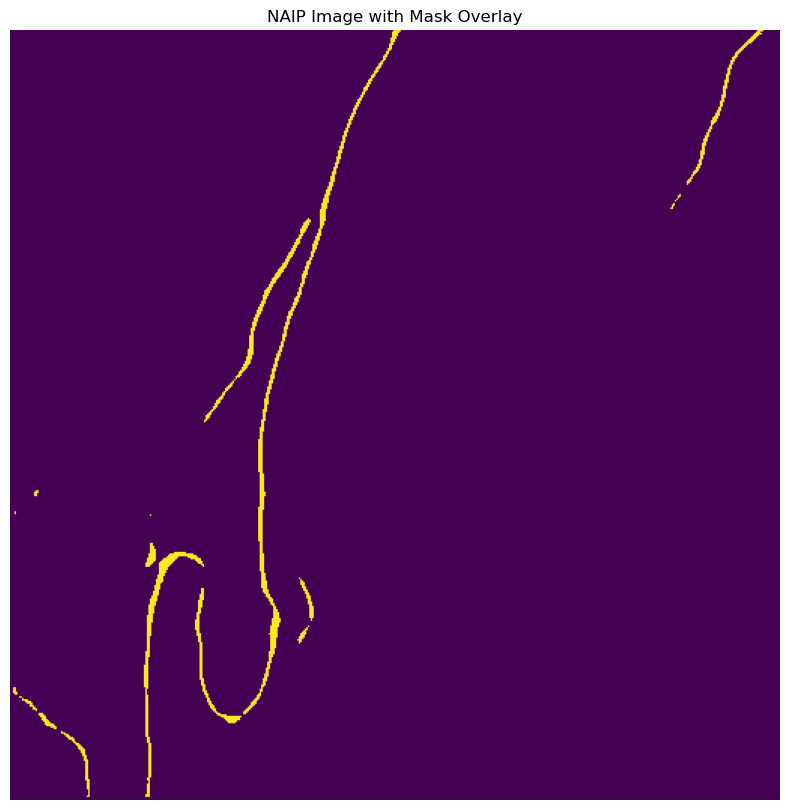

In [6]:
# File path to the NAIP TIFF file
hinaip = rasterio.open("/home/ec2-user/SageMaker/output/RGB/pred_mask_patch5-15.tif").read()
# Select only the RGB bands (assuming NAIP order: Red, Green, Blue, NIR)
rgb_image = hinaip[:3, :, :].astype(np.float32)  # Convert to float32 for processing

# Replace inf values with the 98th percentile of valid (finite) values
finite_mask = np.isfinite(rgb_image)
if np.any(finite_mask):  # Check if there are finite values
    max_finite = np.percentile(rgb_image[finite_mask], 98)
    rgb_image[~finite_mask] = max_finite  # Replace inf with max_finite

# Normalize the image
if hinaip.dtype == np.uint16:
    rgb_image /= 65535
elif hinaip.dtype == np.uint8:
    rgb_image /= 255
else:
    # Normalize using percentile-based scaling to handle outliers
    min_val, max_val = np.percentile(rgb_image, [2, 98])
    rgb_image = np.clip((rgb_image - min_val) / (max_val - min_val), 0, 1)

# Convert back to displayable format
rgb_image = (rgb_image * 255).astype(np.uint8)
# Fix: Proper scaling based on bit-depth
if hinaip.dtype == np.uint16:
    rgb_image /= 65535  # Normalize for 16-bit data
elif hinaip.dtype == np.uint8:
    rgb_image /= 255  # Normalize for 8-bit data
else:
    # Use robust normalization to ignore extreme outliers
    min_val, max_val = np.percentile(rgb_image, [2, 98])
    rgb_image = np.clip((rgb_image - min_val) / (max_val - min_val), 0, 1)

rgb_image = (rgb_image * 255).astype(np.uint8)

mask = rasterio.open("/home/ec2-user/SageMaker/data/train/masks/SCC_mask_patch4-15.tif").read()
if hasattr(mask, "convert"):  # Check if mask is a PIL Image
    mask = np.array(mask)

# Optionally, squeeze mask if it has a singleton channel dimension.
mask = np.squeeze(mask)

# Plot the image and overlay the mask
plt.figure(figsize=(10, 10))
# Transpose the RGB image from (C, H, W) to (H, W, C)
plt.imshow(rgb_image.transpose(1, 2, 0))
# Overlay the mask with a colormap and transparency (alpha)
#plt.imshow(mask, cmap='inferno', alpha=0.5)
plt.title("NAIP Image with Mask Overlay")
plt.axis('off')
plt.show()

In [7]:
class RoadsModel(pl.LightningModule):
    def __init__(self, arch, encoder_name, in_channels, out_classes, **kwargs):
        super().__init__()
        self.model = smp.create_model(
            arch,
            encoder_name=encoder_name,
            in_channels=in_channels,
            classes=out_classes,
            **kwargs,
        )
        # preprocessing parameteres for image
        #params = smp.encoders.get_preprocessing_params(encoder_name)
        #self.register_buffer("std", torch.tensor(params["std"]).view(1, 3, 1, 1))
        #self.register_buffer("mean", torch.tensor(params["mean"]).view(1, 3, 1, 1))

        #  for image segmentation dice loss could be the best first choice
        self.loss_fn = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)

        # initialize step metics
        self.training_step_outputs = []
        self.validation_step_outputs = []
        self.test_step_outputs = []

    def forward(self, image):
        # normalize image here
        image = image.float()
        image = image  # (image - self.mean) / self.std
        mask = self.model(image)
        return mask

    def shared_step(self, batch, stage):
        image = batch["image"]

        # Shape of the image should be (batch_size, num_channels, height, width)
        # if you work with grayscale images, expand channels dim to have [batch_size, 1, height, width]
        assert image.ndim == 4

        # Check that image dimensions are divisible by 32,
        # encoder and decoder connected by `skip connections` and usually encoder have 5 stages of
        # downsampling by factor 2 (2 ^ 5 = 32); e.g. if we have image with shape 65x65 we will have
        # following shapes of features in encoder and decoder: 84, 42, 21, 10, 5 -> 5, 10, 20, 40, 80
        # and we will get an error trying to concat these features
        h, w = image.shape[2:]
        assert h % 32 == 0 and w % 32 == 0

        mask = batch["mask"]
        assert mask.ndim == 4

        # Check that mask values in between 0 and 1, NOT 0 and 255 for binary segmentation
        assert mask.max() <= 1.0 and mask.min() >= 0

        logits_mask = self.forward(image)

        # Predicted mask contains logits, and loss_fn param `from_logits` is set to True
        loss = self.loss_fn(logits_mask, mask)

        # Lets compute metrics for some threshold
        # first convert mask values to probabilities, then
        # apply thresholding
        prob_mask = logits_mask.sigmoid()
        pred_mask = (prob_mask > 0.5).float()

        # We will compute IoU metric by two ways
        #   1. dataset-wise
        #   2. image-wise
        # but for now we just compute true positive, false positive, false negative and
        # true negative 'pixels' for each image and class
        # these values will be aggregated in the end of an epoch
        tp, fp, fn, tn = smp.metrics.get_stats(
            pred_mask.long(), mask.long(), mode="binary"
        )
        return {
            "loss": loss,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
        }

    def shared_epoch_end(self, outputs, stage):
        # aggregate step metics
        tp = torch.cat([x["tp"] for x in outputs])
        fp = torch.cat([x["fp"] for x in outputs])
        fn = torch.cat([x["fn"] for x in outputs])
        tn = torch.cat([x["tn"] for x in outputs])

        # per image IoU means that we first calculate IoU score for each image
        # and then compute mean over these scores
        per_image_iou = smp.metrics.iou_score(
            tp, fp, fn, tn, reduction="micro-imagewise"
        )

        # dataset IoU means that we aggregate intersection and union over whole dataset
        # and then compute IoU score. The difference between dataset_iou and per_image_iou scores
        # in this particular case will not be much, however for dataset
        # with "empty" images (images without target class) a large gap could be observed.
        # Empty images influence a lot on per_image_iou and much less on dataset_iou.
        dataset_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")
        metrics = {
            f"{stage}_per_image_iou": per_image_iou,
            f"{stage}_dataset_iou": dataset_iou,
        }

        self.log_dict(metrics, prog_bar=True)

    def training_step(self, batch, batch_idx):
        train_loss_info = self.shared_step(batch, "train")
        # append the metics of each step to the
        self.training_step_outputs.append(train_loss_info)
        return train_loss_info

    def on_train_epoch_end(self):
        self.shared_epoch_end(self.training_step_outputs, "train")
        # empty set output list
        self.training_step_outputs.clear()
        return

    def validation_step(self, batch, batch_idx):
        valid_loss_info = self.shared_step(batch, "valid")
        self.validation_step_outputs.append(valid_loss_info)
        return valid_loss_info

    def on_validation_epoch_end(self):
        self.shared_epoch_end(self.validation_step_outputs, "valid")
        self.validation_step_outputs.clear()
        return

    def test_step(self, batch, batch_idx):
        test_loss_info = self.shared_step(batch, "test")
        self.test_step_outputs.append(test_loss_info)
        return test_loss_info

    def on_test_epoch_end(self):
        self.shared_epoch_end(self.test_step_outputs, "test")
        # empty set output list
        self.test_step_outputs.clear()
        return

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=2e-4)
        scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_MAX, eta_min=1e-5)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step",
                "frequency": 1,
            },
        }
        return

In [10]:
model = RoadsModel("Unet", "resnet34", in_channels=8, out_classes=1)

EPOCHS = 50
T_MAX = EPOCHS * len(train_dataloader)
OUT_CLASSES = 1

trainer = pl.Trainer(max_epochs=EPOCHS, log_every_n_steps=1)

trainer.fit(
    model,
    train_dataloaders=smashed_dataloader
)

Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]

  | Name    | Type     | Params | Mode 
---------------------------------------------
0 | model   | Unet     | 24.5 M | train
1 | loss_fn | DiceLoss | 0      | train
---------------------------------------------
24.5 M    Trainable params
0         Non-trainable params
24.5 M    Total params
97.808    Total estimated model params size (MB)
189       Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


In [11]:
# run test dataset
test_metrics = trainer.test(model, dataloaders=test_dataloader, verbose=False)
print(test_metrics)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Testing: |          | 0/? [00:00<?, ?it/s]

RuntimeError: Given groups=1, weight of size [64, 8, 7, 7], expected input[32, 4, 512, 512] to have 8 channels, but got 4 channels instead

In [57]:
dummy_input = torch.ones(1, 3, 512, 512)

with torch.no_grad():
    dummy_output = model(dummy_input)

print("Dummy output stats:", dummy_output.min().item(), dummy_output.max().item(), dummy_output.mean().item())

Dummy output stats: -9.640229225158691 5.100529670715332 -5.342748165130615


In [72]:
# Set device and ensure the model is on it
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Directory where you'll save predicted masks
output_dir = "/home/ec2-user/SageMaker/output/RGB/"
os.makedirs(output_dir, exist_ok=True)

test_dir = "/home/ec2-user/SageMaker/data/test/images/"
test_list = os.listdir(test_dir)
for test in test_list:
    test_path = test_dir + test;
    with rasterio.open(test_path) as src:
        meta = src.meta.copy()
    meta.update({"count": 1})

    file_extension = len(test) - 4
    patch_id = ""
    for i, char in enumerate(test):
        if char == "p": # I'm cutting off at the p don't question it
            patch_id = test[i:file_extension]
            break
    
    sample = rasterio.open(test_path).read()
    
    # Convert the sample to a tensor and add a batch dimension.
    # Adjust the slicing if you only want specific channels.
    img_tensor = torch.from_numpy(sample).unsqueeze(0).float().to(device)  # shape: (1, channels, H, W)
    
    # Run model inference.
    with torch.no_grad():
        logits = model(img_tensor)  # Expected output shape: (1, 1, H, W)
    # Convert logits to probabilities and then squeeze the batch and channel dimensions.
    pred_mask = logits.sigmoid().cpu().numpy().squeeze()  # shape: (H, W)
    
    # Optionally, threshold the probabilities to get a binary mask.
    pred_mask_bin = (pred_mask > 0.5).astype(np.uint8)
    
    # Save the predicted mask to a GeoTIFF file
    out_path = os.path.join(output_dir, "pred_mask_" + patch_id + ".tif")
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(pred_mask_bin, 1)  # Write to band 1

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..232.2083333307583].


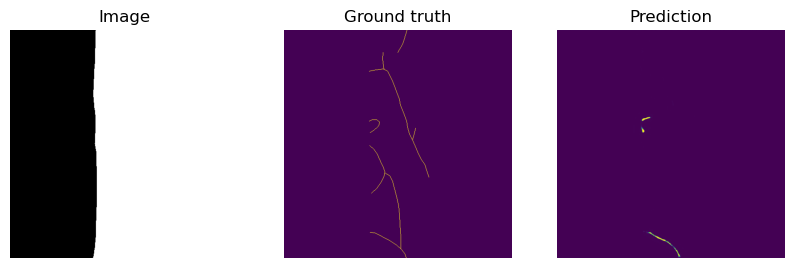

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..217.9629629609069].


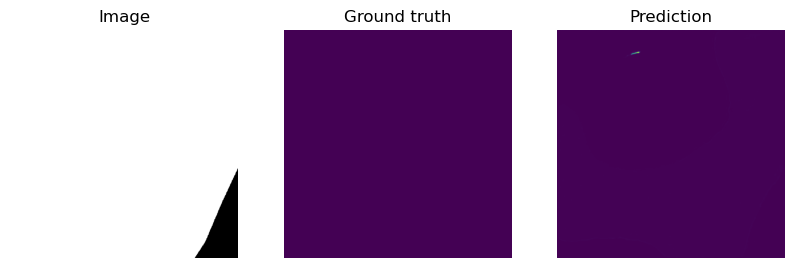

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..179.2777777601051].


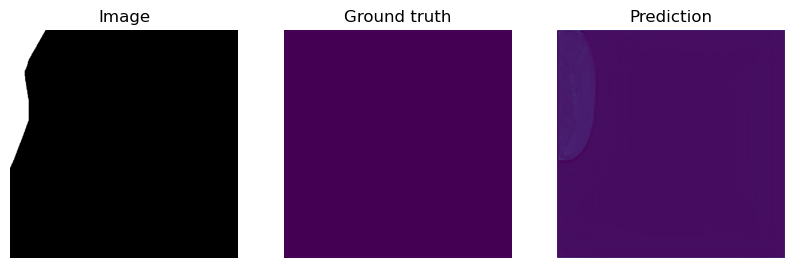

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [32.687500002281226..208.74999999448423].


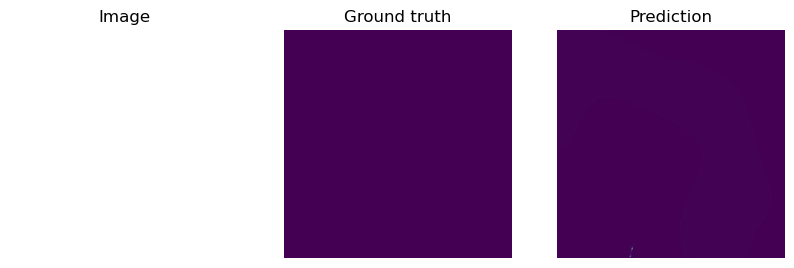

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [19.68055555517893..196.6250000003012].


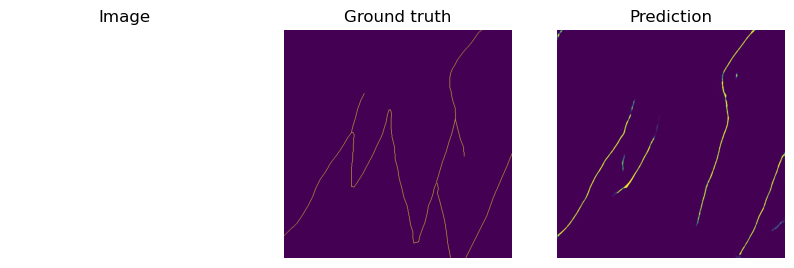

In [58]:
batch = next(iter(test_dataloader))
with torch.no_grad():
    model.eval()
    logits = model(batch["image"])
pr_masks = logits.sigmoid()
for idx, (image, gt_mask, pr_mask) in enumerate(
    zip(batch["image"], batch["mask"], pr_masks)
):
    if idx <= 4:
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(image.numpy().transpose(1, 2, 0))
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(gt_mask.numpy().squeeze())
        plt.title("Ground truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pr_mask.numpy().squeeze())
        plt.title("Prediction")
        plt.axis("off")
        plt.show()
    else:
        break